![Futuristic electric car charging](ev_charging.png)

The US Government's Alternative Fuels Data Center collects records of electric vehicle (EV) charging infrastructure, including charging ports and station locations, as well as sales of electric vehicles. With the EV market rapidly evolving, understanding trends in charging facilities and sales is essential to inform strategic planning.

As a data scientist working for a leading EV charging network operator, you recognize the potential in this data and start wrangling and visualizing the aggregated yearly data. 

This yearly data captured in December of each year encompasses a record of EV charging port installations and station localities spanning roughly ten years, capturing both public and private charging environments. 
___

### The Data
&nbsp;

`private_ev_charging.csv`

| Variable   | Description                                          |
|------------|------------------------------------------------------|
| `year` |  Year of data collection |
| `private_ports`| The number of available charging ports owned by private companies in a given year  |
| `private_station_locations`   | The number of privately owned station locations for EV charging

___

`public_ev_charging.csv`
 
| Variable   | Description                                          |
|------------|------------------------------------------------------|
| `year` |  Year of data collection  |
| `public_ports`| The number of available charging ports under public ownership in a given year  |
| `public_station_locations`   | The number of publicly owned station locations for EV charging

___

The sales information is available for each model and year in the `ev_sales.csv` file:

| Variable   | Description                                          |
|------------|------------------------------------------------------|
| `Vehicle` |  Electric vehicle model |
| `year`| Year of data collection |
| `sales`   | The number of vehicles sold in the US

In [41]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Start coding here
private_ev_charging = pd.read_csv("private_ev_charging.csv")
public_ev_charging = pd.read_csv("public_ev_charging.csv")
ev_sales = pd.read_csv("ev_sales.csv")
print(private_ev_charging.head())
print(public_ev_charging.head())
print(ev_sales.head())


   year  private_ports  private_station_locations
0  2014           3695                       1825
1  2015           4150                       1962
2  2016           5763                       2331
3  2017           6048                       2370
4  2018           6812                       2489
   year  public_ports  public_station_locations
0  2013         16619                      6938
1  2014         22470                      9207
2  2015         26532                     10710
3  2016         33165                     13150
4  2017         45789                     16170
      Vehicle  year    sales
0  Chevy Volt  2011   7671.0
1  Chevy Volt  2012  23461.0
2  Chevy Volt  2013  23094.0
3  Chevy Volt  2014  18805.0
4  Chevy Volt  2015  15393.0


In [43]:
pubic_and_private = public_ev_charging.merge(private_ev_charging, on = "year", how = "outer", indicator = True)
public_and_private_filt = pubic_and_private[pubic_and_private["_merge"] == "both" ]
public_and_private_filt.drop("_merge", axis = 1, inplace = True)
print(public_and_private_filt.head())




   year  public_ports  ...  private_ports  private_station_locations
1  2014         22470  ...         3695.0                     1825.0
2  2015         26532  ...         4150.0                     1962.0
3  2016         33165  ...         5763.0                     2331.0
4  2017         45789  ...         6048.0                     2370.0
5  2018         56842  ...         6812.0                     2489.0

[5 rows x 5 columns]


In [44]:
sales =ev_sales.groupby("year").sum()
sales_public_private = public_and_private_filt.merge(sales, on = "year", how = "left")
sales_public_private.reset_index()


,index,year,public_ports,public_station_locations,private_ports,private_station_locations,sales
0,0,2014,22470,9207,3695.0,1825.0,118882.0
1,1,2015,26532,10710,4150.0,1962.0,114023.0
2,2,2016,33165,13150,5763.0,2331.0,159616.0
3,3,2017,45789,16170,6048.0,2370.0,195581.0
4,4,2018,56842,19893,6812.0,2489.0,361315.0
5,5,2019,73838,23282,9955.0,3078.0,326644.0
6,6,2020,96190,28602,10647.0,2768.0,NaN
7,7,2021,114451,46407,18867.0,4074.0,NaN
8,8,2022,136513,53764,19993.0,4435.0,NaN


In [45]:
# Filter the row for 2018 and get the sales value
ev_sales_2018 = sales_public_private[sales_public_private["year"] == 2018]["sales"].values[0]

print(ev_sales_2018)

361315.0


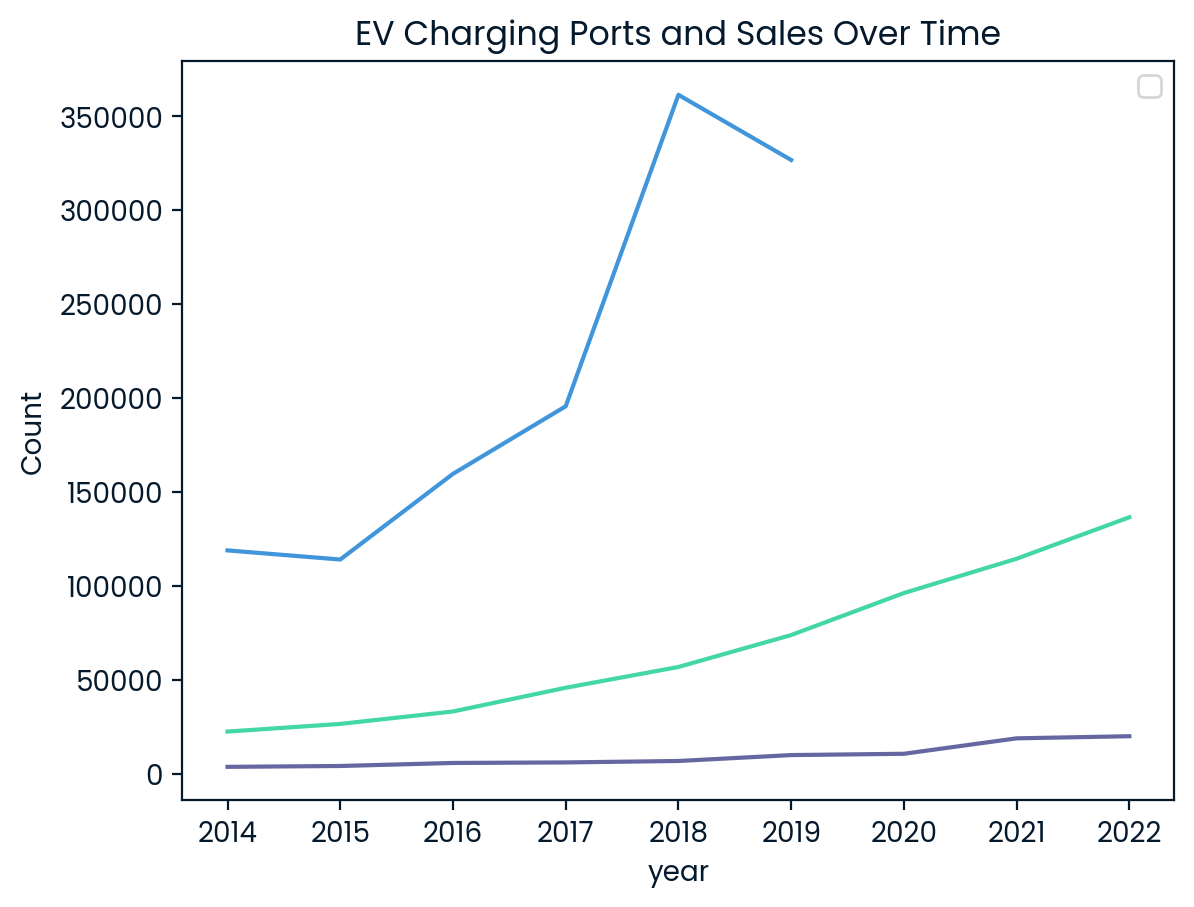

In [46]:
fig, ax = plt.subplots()

sns.lineplot(data= sales_public_private, x="year", y="private_ports", ax=ax)
sns.lineplot(data=sales_public_private, x="year", y="public_ports", ax=ax)
sns.lineplot(data=sales_public_private, x="year", y="sales", ax=ax)
ax.set_title("EV Charging Ports and Sales Over Time")
ax.set_ylabel("Count")
ax.legend()

In [47]:
trend = "same"